Columns in dataset: ['DATE', 'T10Y3M', 'CPI', 'S&P500', 'Median_House_Price', 'UNRATE', 'USREC', 'USOIL']
Shape: (758, 8)

Features used: ['USOIL', 'UNRATE_6m_change', 'UNRATE_3m_change', 'S&P500', 'T10Y3M_lagged_9m', 'T10Y3M_lagged_12m', 'CPI', 'CPI_12m_change', 'Median_House_Price']

Class distribution:
USREC
0    661
1     85
Name: count, dtype: int64

Cross-Validation Accuracy Scores (TimeSeriesSplit): [0.80645161 0.99193548 0.93548387 0.84677419 0.99193548]
Mean Accuracy: 0.915 (±0.076)

Confusion Matrix:
[[128   5]
 [  3  14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       133
           1       0.74      0.82      0.78        17

    accuracy                           0.95       150
   macro avg       0.86      0.89      0.87       150
weighted avg       0.95      0.95      0.95       150

AUC Score: 0.984


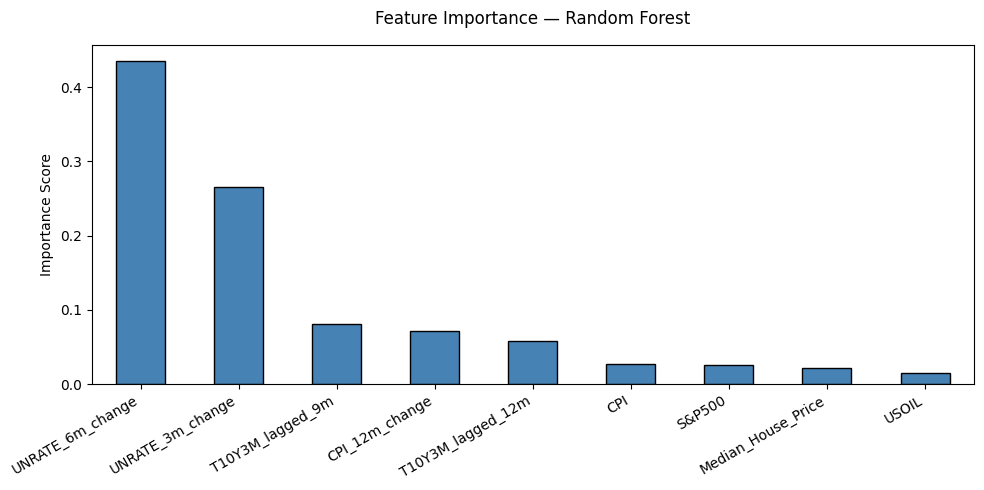

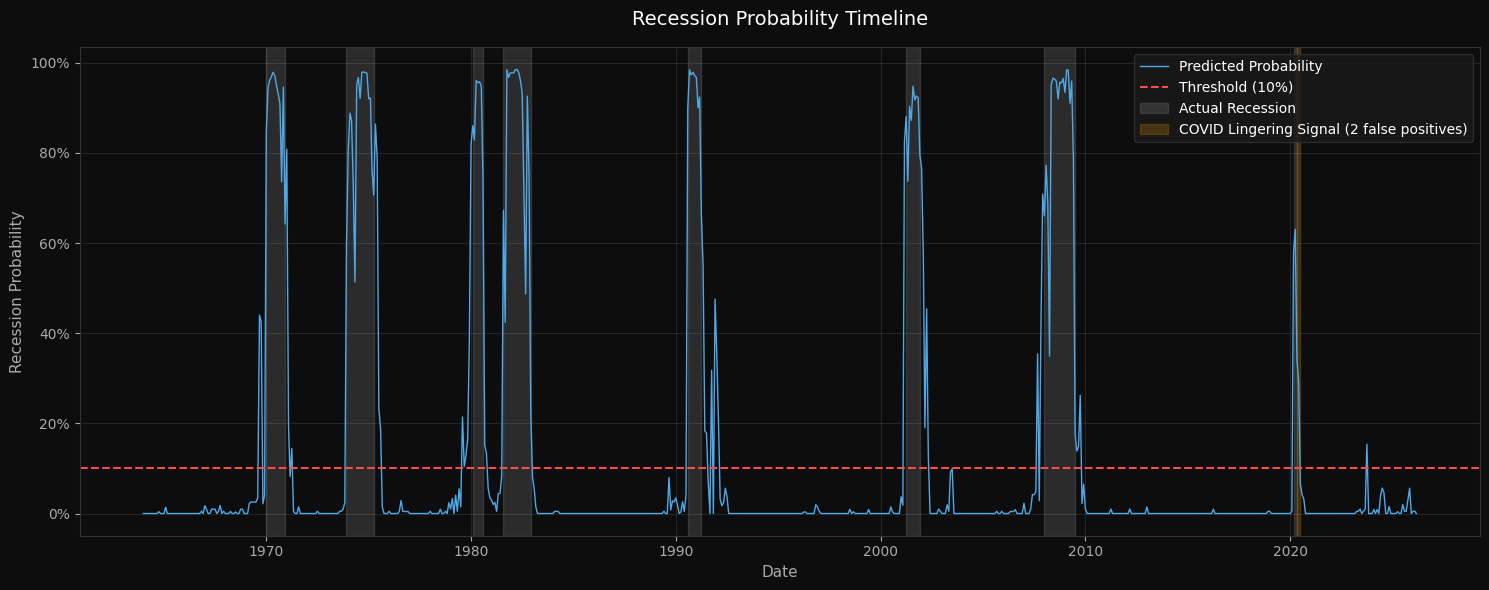

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# STEP 1 — Load and prepare data
# ─────────────────────────────────────────────
df = pd.read_csv("dataset for recession.csv", parse_dates=["DATE"])
df = df.dropna()

# Fix column names so features are recognised
df = df.rename(columns={"WTISPLC": "USOIL", "SP500": "S&P500"})

print("Columns in dataset:", df.columns.tolist())
print(f"Shape: {df.shape}")

# ─────────────────────────────────────────────
# STEP 2 — Feature Engineering
# ─────────────────────────────────────────────
df['T10Y3M_lagged_9m']  = df['T10Y3M'].shift(9)       # Yield curve lagged 9 months
df['T10Y3M_lagged_12m'] = df['T10Y3M'].shift(12)      # Yield curve lagged 12 months
df['UNRATE_6m_change']  = df['UNRATE'].diff(6)         # Unemployment 6-month change
df['UNRATE_3m_change']  = df['UNRATE'].diff(3)         # Unemployment 3-month change
df['CPI_12m_change']    = df['CPI'].pct_change(12)     # Year-over-year inflation

df = df.dropna()  # Drop rows that became NaN after engineering

# ─────────────────────────────────────────────
# STEP 3 — Define Features & Target
# ─────────────────────────────────────────────
feature_cols = [
    'USOIL',
    'UNRATE_6m_change',
    'UNRATE_3m_change',
    'S&P500',
    'T10Y3M_lagged_9m',
    'T10Y3M_lagged_12m',
    'CPI',
    'CPI_12m_change',
    'Median_House_Price'
]

# Keep only columns that exist in the dataframe
feature_cols = [c for c in feature_cols if c in df.columns]
print(f"\nFeatures used: {feature_cols}")

X = df[feature_cols]
y = df['USREC']

print(f"\nClass distribution:\n{y.value_counts()}")

# ─────────────────────────────────────────────
# STEP 4 — Train / Test Split
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ─────────────────────────────────────────────
# STEP 5 — Random Forest Model (improved)
# ─────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,     # More trees for stability
    max_depth=6,          # Prevents overfitting
    class_weight='balanced',
    random_state=42
)

# TimeSeriesSplit cross-validation (respects time order, no future leakage)
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(rf_model, X, y, cv=tscv, scoring='accuracy')
print(f"\nCross-Validation Accuracy Scores (TimeSeriesSplit): {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.3f} (±{cv_scores.std():.3f})")

# Train on training set
rf_model.fit(X_train, y_train)

# Evaluate on test set
y_pred       = rf_model.predict(X_test)
y_proba_test = rf_model.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"AUC Score: {roc_auc_score(y_test, y_proba_test):.3f}")

# ─────────────────────────────────────────────
# STEP 6 — Feature Importance
# ─────────────────────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Feature Importance — Random Forest", pad=15)
plt.ylabel("Importance Score")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# STEP 7 — Recession Probability Timeline
# ─────────────────────────────────────────────
custom_threshold = 0.10
df['Recession_Prob'] = rf_model.predict_proba(X)[:, 1]

plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor('#0D0D0D')
ax.set_facecolor('#0D0D0D')

ax.plot(df['DATE'], df['Recession_Prob'], label='Predicted Probability', color='#4FA8E8', linewidth=1)
ax.axhline(custom_threshold, color='#FF4C4C', linestyle='--', label=f'Threshold ({custom_threshold:.0%})')

# Shade actual recession periods
start = None
for i in range(1, len(df)):
    if df['USREC'].iloc[i] == 1 and df['USREC'].iloc[i-1] == 0:
        start = df['DATE'].iloc[i]
    elif df['USREC'].iloc[i] == 0 and df['USREC'].iloc[i-1] == 1 and start is not None:
        ax.axvspan(start, df['DATE'].iloc[i], color='#888888', alpha=0.25, label='Actual Recession')
        start = None

# COVID false positives
ax.axvspan(pd.Timestamp('2020-05-01'), pd.Timestamp('2020-07-01'),
           color='#FFA500', alpha=0.2, label='COVID Lingering Signal (2 false positives)')

# Formatting
ax.set_title("Recession Probability Timeline", color='white', fontsize=14, pad=16)
ax.set_xlabel("Date", color='#AAAAAA', fontsize=11)
ax.set_ylabel("Recession Probability", color='#AAAAAA', fontsize=11)
ax.tick_params(colors='#AAAAAA', labelsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.grid(True, alpha=0.1, color='white')
for spine in ax.spines.values():
    spine.set_color('#333333')

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(),
          facecolor='#1A1A1A', edgecolor='#333333',
          labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('recession_timeline.png', dpi=150, bbox_inches='tight',
            facecolor='#0D0D0D')
plt.show()

In [3]:
# Full dataset false positive analysis
df['Predicted'] = rf_model.predict(X)
df['Flagged_Prob'] = (df['Recession_Prob'] >= 0.10).astype(int)

# Using probability threshold (what the chart shows)
fp_prob = df[(df['Flagged_Prob'] == 1) & (df['USREC'] == 0)]
fn_prob = df[(df['Flagged_Prob'] == 0) & (df['USREC'] == 1)]

print(f"=== Full Dataset (Probability Threshold 10%) ===")
print(f"Total months: {len(df)}")
print(f"False positives: {len(fp_prob)}")
print(f"Missed recessions: {len(fn_prob)}")
print(f"\nFalse positive months:")
print(fp_prob[['DATE','USREC','Recession_Prob']].to_string(index=False))
print(f"\nMissed recession months:")
print(fn_prob[['DATE','USREC','Recession_Prob']].to_string(index=False))

=== Full Dataset (Probability Threshold 10%) ===
Total months: 746
False positives: 46
Missed recessions: 0

False positive months:
      DATE  USREC  Recession_Prob
1969-09-01      0        0.439989
1969-10-01      0        0.425972
1970-12-01      0        0.642499
1971-01-01      0        0.808457
1971-02-01      0        0.194087
1971-04-01      0        0.144121
1975-04-01      0        0.706882
1975-05-01      0        0.864241
1975-06-01      0        0.790656
1975-07-01      0        0.233655
1975-08-01      0        0.187203
1979-08-01      0        0.214503
1979-09-01      0        0.104191
1979-10-01      0        0.128313
1979-11-01      0        0.163406
1979-12-01      0        0.381309
1980-01-01      0        0.818656
1980-08-01      0        0.742348
1980-09-01      0        0.152650
1980-10-01      0        0.133216
1982-12-01      0        0.221595
1991-04-01      0        0.661274
1991-05-01      0        0.552922
1991-06-01      0        0.183505
1991-07-01      0 

In [3]:
# Isolate 2020 COVID period
covid = df[(df['DATE'] >= '2019-01-01') & (df['DATE'] <= '2021-06-01')][['DATE','USREC','Recession_Prob']].copy()
covid['Flagged'] = (covid['Recession_Prob'] >= 0.10).astype(int)

print("2020 COVID period breakdown:")
print(covid[['DATE','USREC','Recession_Prob','Flagged']].to_string(index=False))

print(f"\nMonths flagged as recession: {covid['Flagged'].sum()}")
print(f"Months actually in recession (USREC=1): {covid['USREC'].sum()}")
print(f"False positives (flagged but USREC=0): {((covid['Flagged']==1) & (covid['USREC']==0)).sum()}")
print(f"Missed months (not flagged but USREC=1): {((covid['Flagged']==0) & (covid['USREC']==1)).sum()}")

2020 COVID period breakdown:
      DATE  USREC  Recession_Prob  Flagged
2019-01-01      0        0.004848        0
2019-02-01      0        0.000000        0
2019-03-01      0        0.000000        0
2019-04-01      0        0.000000        0
2019-05-01      0        0.000000        0
2019-06-01      0        0.000000        0
2019-07-01      0        0.000000        0
2019-08-01      0        0.000000        0
2019-09-01      0        0.000000        0
2019-10-01      0        0.000000        0
2019-11-01      0        0.000000        0
2019-12-01      0        0.000000        0
2020-01-01      0        0.000000        0
2020-02-01      0        0.005000        0
2020-03-01      1        0.580812        1
2020-04-01      1        0.630509        1
2020-05-01      0        0.340062        1
2020-06-01      0        0.290668        1
2020-07-01      0        0.065830        0
2020-08-01      0        0.041507        0
2020-09-01      0        0.031568        0
2020-10-01      0        

In [11]:
# Isolate 2022 flagged period
period_2022 = df[(df['DATE'] >= '2021-06-01') & (df['DATE'] <= '2023-12-01')][['DATE','USREC','Recession_Prob']].copy()
period_2022['Flagged'] = (period_2022['Recession_Prob'] >= 0.10).astype(int)

print("2022 period breakdown:")
print(period_2022[['DATE','USREC','Recession_Prob','Flagged']].to_string(index=False))

print(f"\nMonths flagged as recession: {period_2022['Flagged'].sum()}")
print(f"Months actually in recession (USREC=1): {period_2022['USREC'].sum()}")
print(f"False positives: {((period_2022['Flagged']==1) & (period_2022['USREC']==0)).sum()}")

2022 period breakdown:
      DATE  USREC  Recession_Prob  Flagged
2021-06-01      0        0.000000        0
2021-07-01      0        0.000000        0
2021-08-01      0        0.000000        0
2021-09-01      0        0.000000        0
2021-10-01      0        0.000000        0
2021-11-01      0        0.000000        0
2021-12-01      0        0.000000        0
2022-01-01      0        0.000000        0
2022-02-01      0        0.000000        0
2022-03-01      0        0.000000        0
2022-04-01      0        0.000000        0
2022-05-01      0        0.000000        0
2022-06-01      0        0.000000        0
2022-07-01      0        0.000000        0
2022-08-01      0        0.000000        0
2022-09-01      0        0.000000        0
2022-10-01      0        0.000000        0
2022-11-01      0        0.000000        0
2022-12-01      0        0.000000        0
2023-01-01      0        0.000000        0
2023-02-01      0        0.000000        0
2023-03-01      0        0.0000